# Set up
importing data, setting up globals, and helper functions for fitting

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

pv, pyr = pd.read_excel('results_drugs.xlsx', sheet_name="PV"), pd.read_excel('results_drugs.xlsx', sheet_name="pyramidal")
distances = [50, 100, 250, 750]
intensities = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0]
def sigmoid(x, L, x0, k):
    return L / (1 + np.exp(k * (x - x0)))

p=6
def gauss(x, I, R, sigma):
    return np.exp(-x**2 / (sigma +(R * I)**(2/p+2)))


getting the mean probability of spiking $y$ at a distance $x$

In [14]:
pyr_data, pv_data = {}, {}

for intensity in pyr["Intensity"].unique():
    pyr_subset = pyr[pyr["Intensity"] == intensity]
    pv_subset = pv[pv["Intensity"] == intensity]

    x1, x2, y1, y2 = [], [], [], []

    for dist in distances:
        y_mean1 = pyr_subset[pyr_subset["Distance"] == dist]["mean_Spp"].mean()
        x1.append(dist)
        y1.append(1 if np.isnan(y_mean1) else y_mean1)

        y_mean2 = pv_subset[pv_subset["Distance"] == dist]["mean_Spp"].mean()
        x2.append(dist)
        y2.append(1 if np.isnan(y_mean2) else y_mean2)

    pyr_data[intensity] = {
        "x": np.array(x1),
        "y": np.array(y1)
    }

    pv_data[intensity] = {
        "x": np.array(x2),
        "y": np.array(y2)
    }


Plotting the cleaned up data above at every intensity.

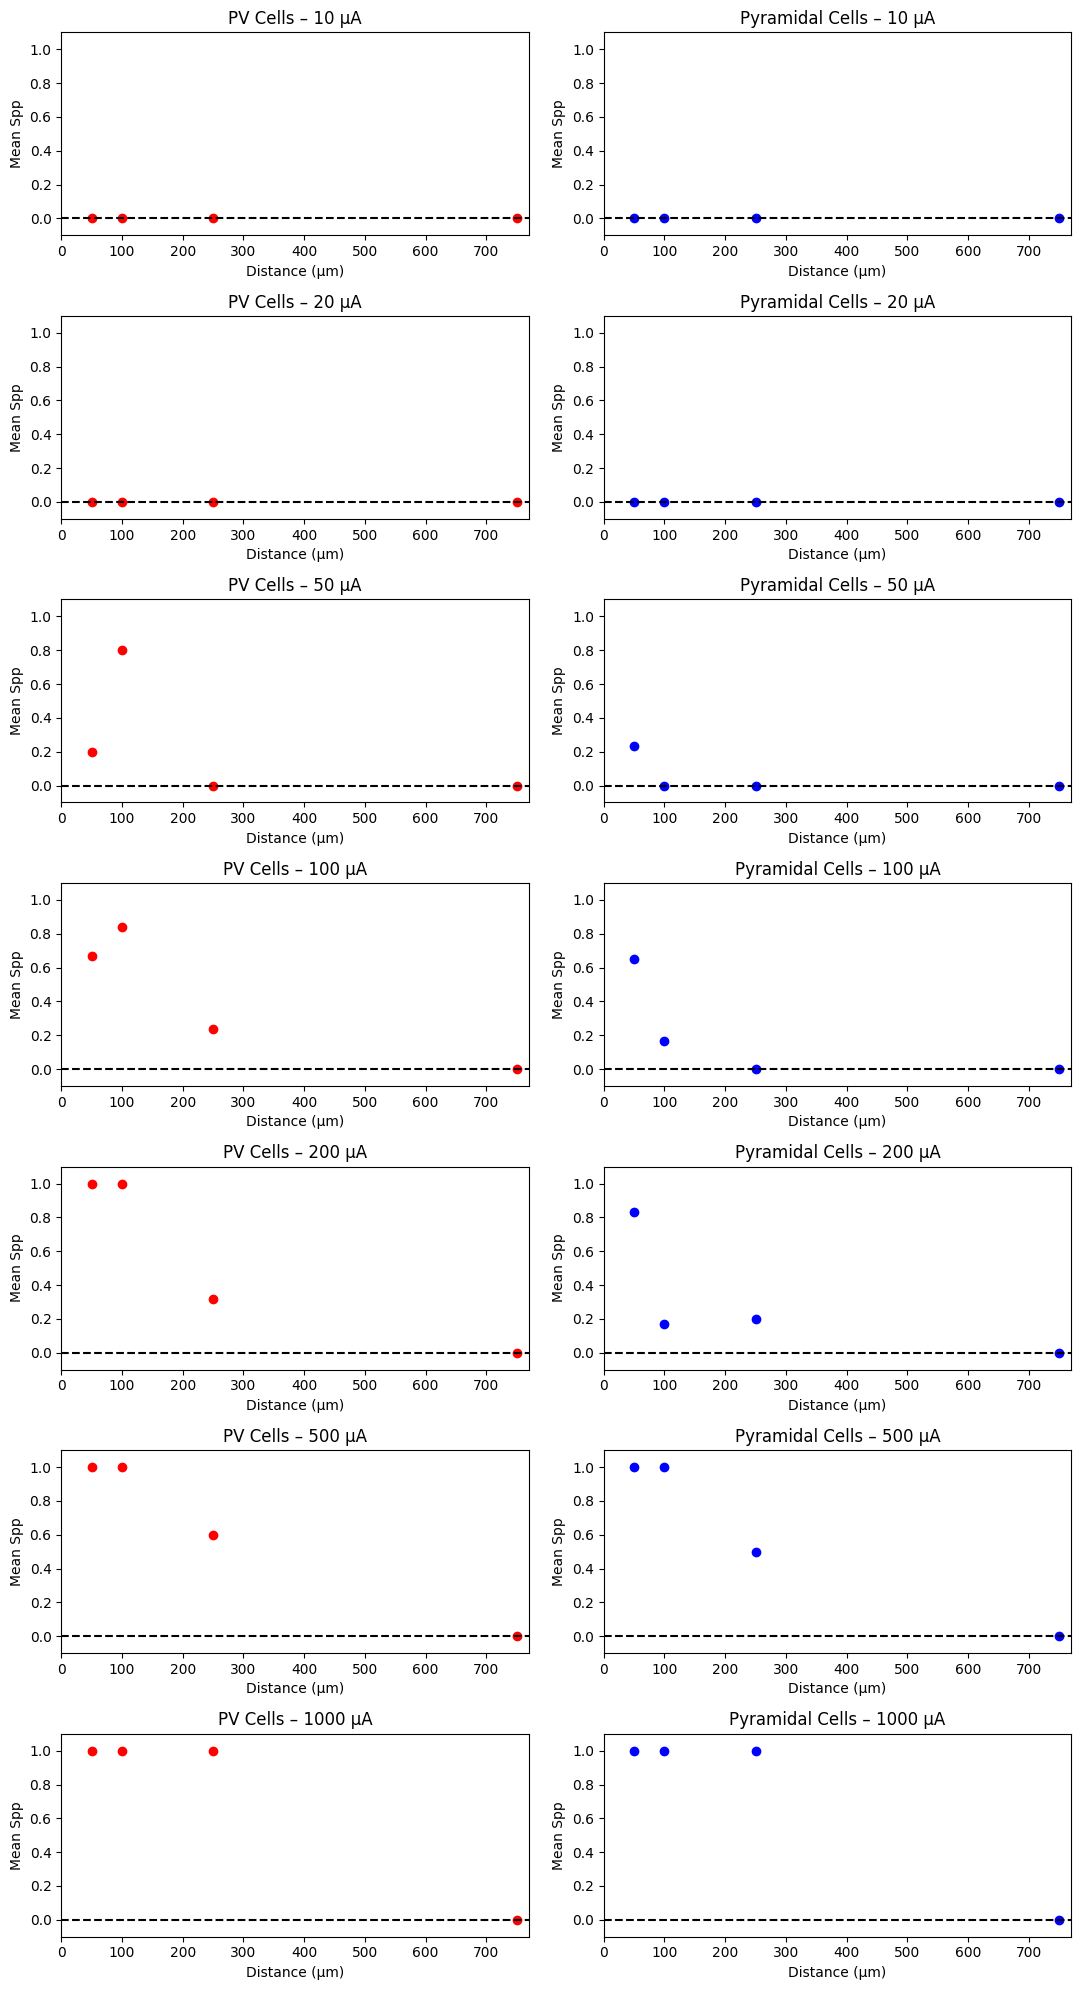

In [15]:
fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(11, 20))

axes = axes.flatten()  # make indexing easier

count = 0
for intensity in intensities:
    ax = axes[count]
    data = pv_data[intensity]
    ax.scatter(distances, data["y"], color='red', label='Data Points')
    ax.set_title(f'PV Cells – {intensity*1000:.0f} μA')
    ax.hlines(y=0, xmin=0, xmax=770, colors='k', linestyles='dashed')
    ax.set_ylim(-0.1, 1.1)
    ax.set_xlim(0, 770)
    ax.set_xlabel('Distance (μm)')
    ax.set_ylabel('Mean Spp')

    count += 1
    ax = axes[count]
    data = pyr_data[intensity]
    ax.scatter(distances, data["y"], color='blue', label='Data Points')
    ax.set_title(f'Pyramidal Cells – {intensity*1000:.0f} μA')
    ax.hlines(y=0, xmin=0, xmax=770, colors='k', linestyles='dashed')
    ax.set_ylim(-0.1, 1.1)
    ax.set_xlim(0, 770)
    ax.set_xlabel('Distance (μm)')
    ax.set_ylabel('Mean Spp')
    count += 1


plt.tight_layout()
plt.show()

helper function to guess the best fit to the data with the sigmoidal function.

In [16]:
def best_guess(x, y):
    """Estimate initial parameters for sigmoid fitting."""
    L = np.max(y)
    x0 = x[np.argmin(np.abs(y - 0.5))]
    k = 0.1  # A small positive value
    return [L, x0, k]

In [17]:
pyr_fits, pv_fits = {}, {}

for intensity, vals in pyr_data.items():
    x = vals["x"]
    y= vals["y"]
    
    p0 = best_guess(x, y)
    
    try:
        params1, cov1 = curve_fit(sigmoid, x, y)
    except RuntimeError as e: 
        print("Pyr:", e, " for intensity", intensity)
    
    pyr_fits[intensity] = params1

for intensity, vals in pv_data.items():
    x = vals["x"]
    y= vals["y"]
    p0 = best_guess(x, y)

    try:
        params2, cov2 = curve_fit(sigmoid, x, y, p0=p0)
    except RuntimeError as e:
        print("PV:", e, " for intensity", intensity)
    
    pv_fits[intensity] = params2


PV: Optimal parameters not found: Number of calls to function has reached maxfev = 800.  for intensity 0.2
PV: Optimal parameters not found: Number of calls to function has reached maxfev = 800.  for intensity 0.5


/var/folders/fj/pq0251sj5ld5q6zfbcdblzkc0000gn/T/ipykernel_41360/3413892137.py:10: RuntimeWarning: overflow encountered in exp
  return L / (1 + np.exp(k * (x - x0)))
/Users/maxpiatine/Developer/thesis/.venv/lib/python3.13/site-packages/scipy/optimize/_minpack_py.py:497: RuntimeWarning: overflow encountered in matmul
  cov_x = invR @ invR.T
/var/folders/fj/pq0251sj5ld5q6zfbcdblzkc0000gn/T/ipykernel_41360/3987552215.py:10: OptimizeWarning: Covariance of the parameters could not be estimated
  params1, cov1 = curve_fit(sigmoid, x, y)
/var/folders/fj/pq0251sj5ld5q6zfbcdblzkc0000gn/T/ipykernel_41360/3987552215.py:22: OptimizeWarning: Covariance of the parameters could not be estimated
  params2, cov2 = curve_fit(sigmoid, x, y, p0=p0)


plotting best fit with the data

/var/folders/fj/pq0251sj5ld5q6zfbcdblzkc0000gn/T/ipykernel_41360/3413892137.py:10: RuntimeWarning: overflow encountered in exp
  return L / (1 + np.exp(k * (x - x0)))


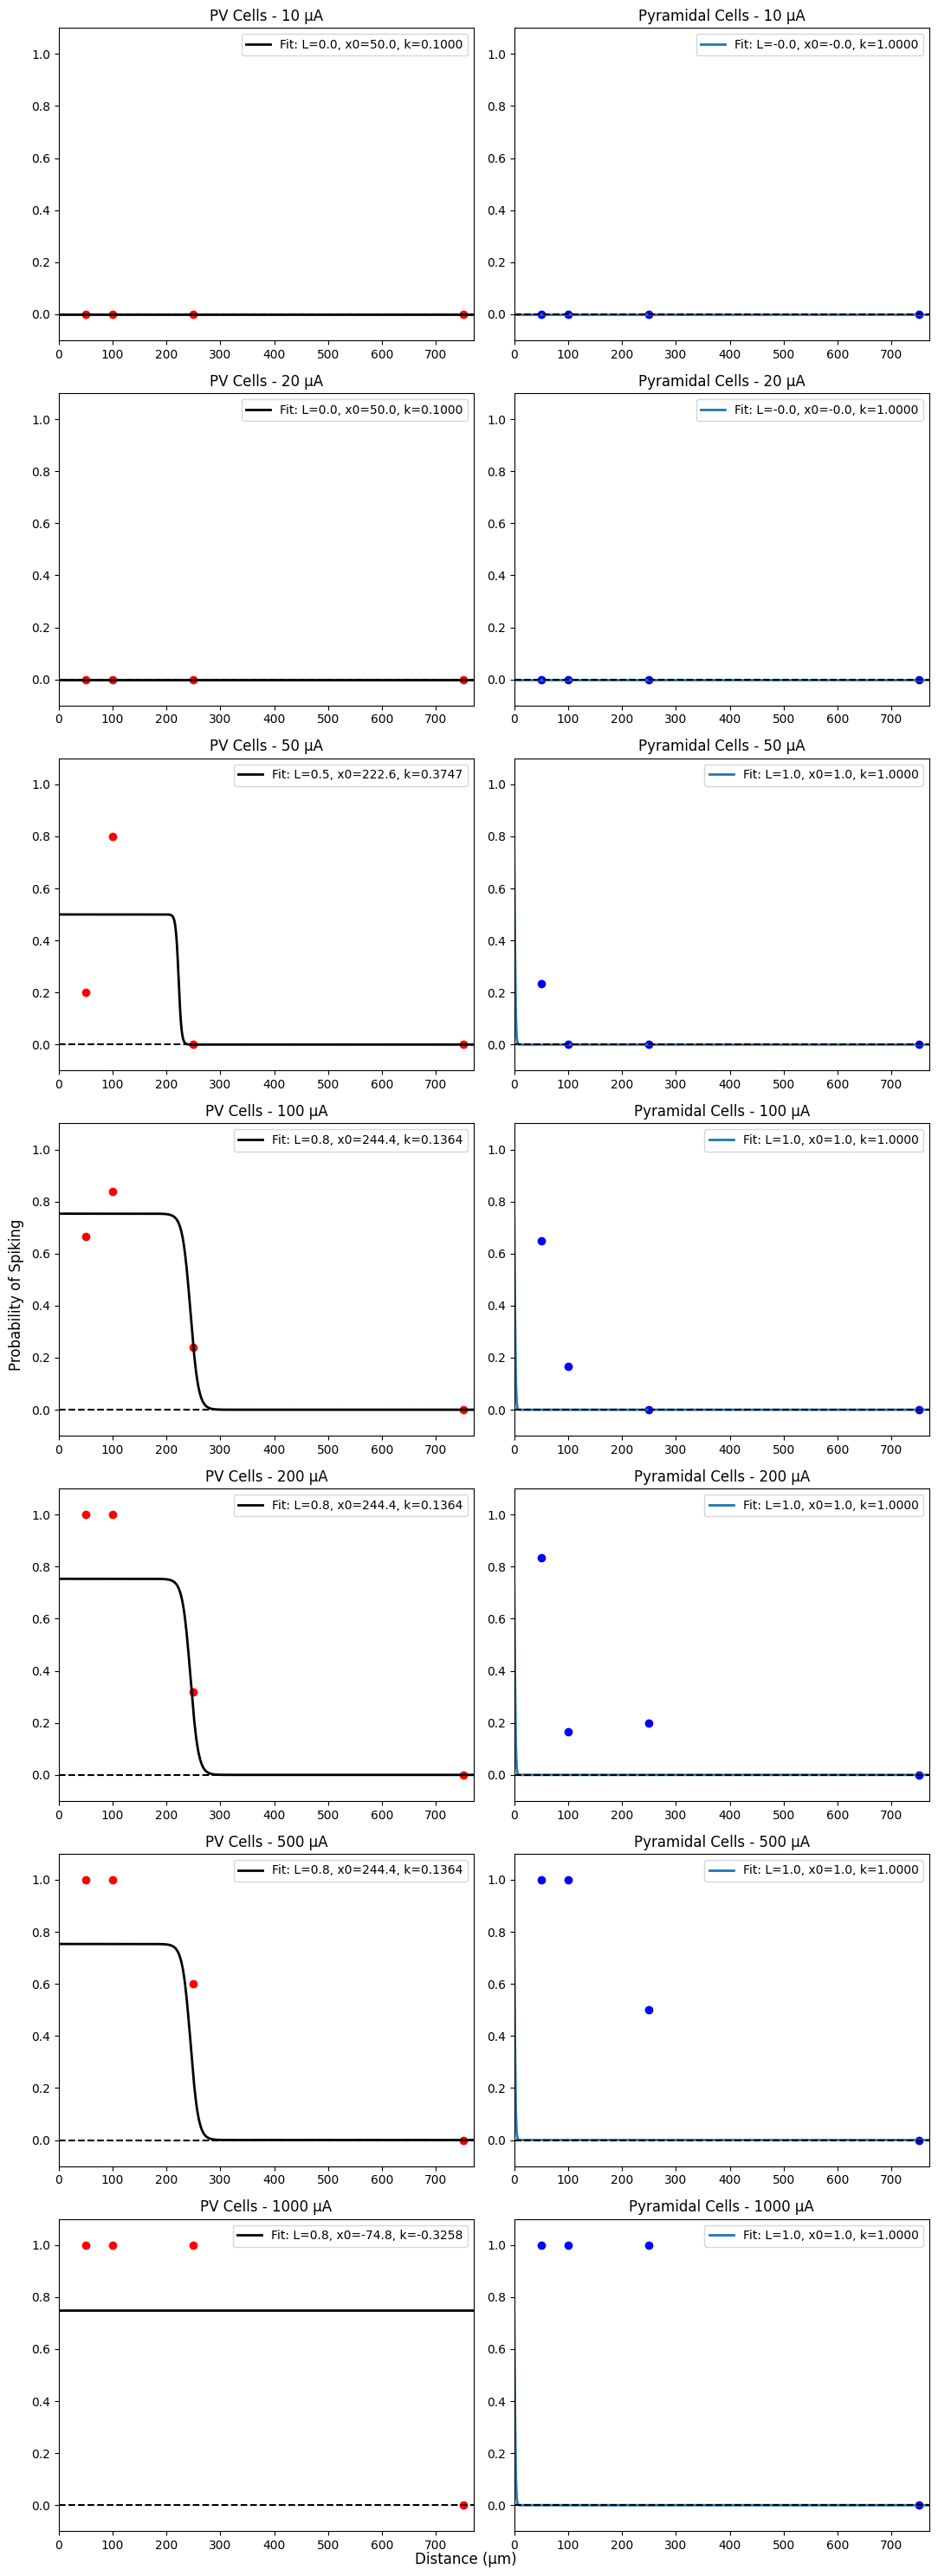

In [18]:
fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(11, 30))
axes = axes.flatten()  

x_fit = np.linspace(0, 770, 500)
count = 0
for intensity in intensities:
    ax = axes[count]

    data = pv_data[intensity]
    ax.scatter(distances, data["y"], color='red')

    L, x0, k = pv_fits[intensity]
    ax.plot(x_fit, sigmoid(x_fit, L, x0, k),
            label=f"Fit: L={L:.1f}, x0={x0:.1f}, k={k:.4f}",
            linewidth=2, color="k")
    
    ax.axhline(0, color='k', linestyle='dashed')
    ax.set_ylim(-0.1, 1.1)
    ax.set_xlim(0, 770)
    ax.set_title(f"PV Cells - {intensity*1000:.0f} μA")
    ax.legend()

    count += 1

    ax = axes[count]

    y = pyr_data[intensity]["y"]
    ax.scatter(distances, y, color='blue')

    L, x0, k = pyr_fits[intensity]
    ax.plot(x_fit, sigmoid(x_fit, L, x0, k),
            label=f"Fit: L={L:.1f}, x0={x0:.1f}, k={k:.4f}",
            linewidth=2)

    ax.axhline(0, color='k', linestyle='dashed')
    ax.set_ylim(-0.1, 1.1)
    ax.set_xlim(0, 770)
    ax.set_title(f"Pyramidal Cells - {intensity*1000:.0f} μA")
    ax.legend()

    count += 1

fig.supylabel("Probability of Spiking")
fig.supxlabel("Distance (μm)")
fig.subplots_adjust(top=0.85)
plt.tight_layout()
plt.show()


## Gaussian attempt

with the standard deviation changes.

In [80]:

def gauss_fit(I):
    def model(x, R, sigma):
        return np.exp(-x**2 / (sigma + (R * I)**(2/p+2)))
    return model

In [81]:
pyr_fits, pv_fits = {}, {}

for intensity, vals in pyr_data.items():
    x = vals["x"]
    y= vals["y"]
    
    p0 = [0.5, 100]
    
    try:
        params1, cov1 = curve_fit(gauss_fit(intensity*1000), x, y, p0)
    except RuntimeError as e: 
        print("Pyr:", e, " for intensity", intensity)
    
    pyr_fits[intensity] = params1

for intensity, vals in pv_data.items():
    x = vals["x"]
    y= vals["y"]
    p0 = [0.5, 100]

    try:
        params2, cov2 = curve_fit(gauss_fit(intensity*1000), x, y, p0=p0)
    except RuntimeError as e:
        print("PV:", e, " for intensity", intensity)
    
    pv_fits[intensity] = params2


Pyr: Optimal parameters not found: Number of calls to function has reached maxfev = 600.  for intensity 0.01
Pyr: Optimal parameters not found: Number of calls to function has reached maxfev = 600.  for intensity 0.02
PV: Optimal parameters not found: Number of calls to function has reached maxfev = 600.  for intensity 0.01
PV: Optimal parameters not found: Number of calls to function has reached maxfev = 600.  for intensity 0.02


/var/folders/fj/pq0251sj5ld5q6zfbcdblzkc0000gn/T/ipykernel_41360/41611443.py:3: RuntimeWarning: invalid value encountered in scalar power
  return np.exp(-x**2 / (sigma + (R * I)**(2/p+2)))


/var/folders/fj/pq0251sj5ld5q6zfbcdblzkc0000gn/T/ipykernel_41360/41611443.py:3: RuntimeWarning: invalid value encountered in scalar power
  return np.exp(-x**2 / (sigma + (R * I)**(2/p+2)))


Pyr: Optimal parameters not found: Number of calls to function has reached maxfev = 600.  for intensity 0.01
Pyr: Optimal parameters not found: Number of calls to function has reached maxfev = 600.  for intensity 0.02
PV: Optimal parameters not found: Number of calls to function has reached maxfev = 600.  for intensity 0.01
PV: Optimal parameters not found: Number of calls to function has reached maxfev = 600.  for intensity 0.02


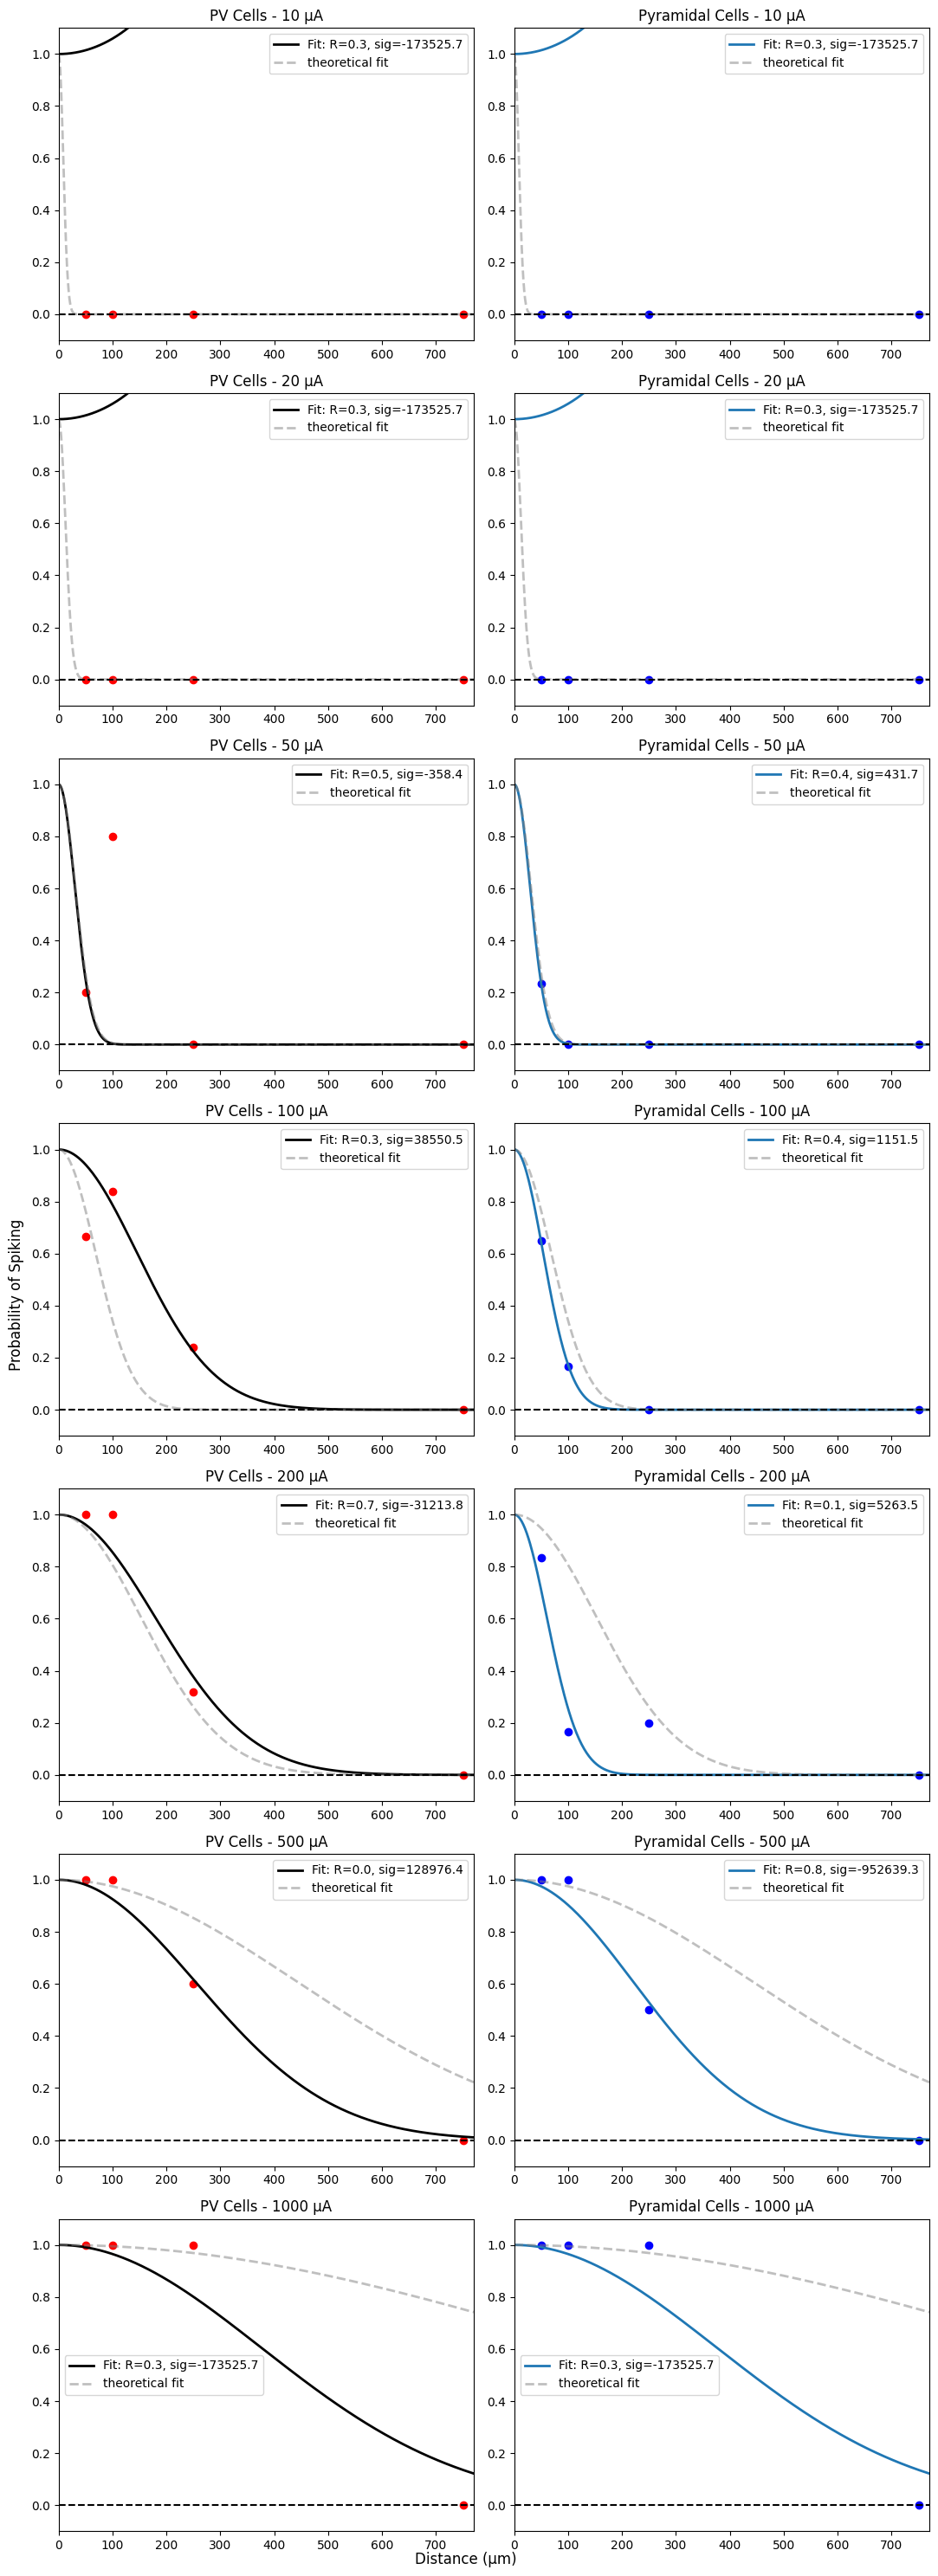

In [82]:
pyr_fits, pv_fits = {}, {}

for intensity, vals in pyr_data.items():
    x = vals["x"]
    y= vals["y"]
    
    p0 = [0.5, 100]
    
    try:
        params1, cov1 = curve_fit(gauss_fit(intensity*1000), x, y, p0)
    except RuntimeError as e: 
        print("Pyr:", e, " for intensity", intensity)
    
    pyr_fits[intensity] = params1

for intensity, vals in pv_data.items():
    x = vals["x"]
    y= vals["y"]
    p0 = [0.5, 100]

    try:
        params2, cov2 = curve_fit(gauss_fit(intensity*1000), x, y, p0=p0)
    except RuntimeError as e:
        print("PV:", e, " for intensity", intensity)
    
    pv_fits[intensity] = params2


fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(11, 30))
axes = axes.flatten()  

x_fit = np.linspace(0, 770, 500)
count = 0
for intensity in intensities:
    ax = axes[count]

    data = pv_data[intensity]
    ax.scatter(distances, data["y"], color='red')

    R, sigma = pv_fits[intensity]
    ax.plot(x_fit, gauss(x_fit, intensity*1000, R, sigma),
            label=f"Fit: R={R:.1f}, sig={sigma:.1f}",
            linewidth=2, color="k")
    ax.plot(x_fit, gauss(x_fit, intensity*1000, 0.5, 100),
            label=f"theoretical fit",
            linewidth=2, color="gray", alpha=0.5, linestyle='dashed')
    ax.axhline(0, color='k', linestyle='dashed')
    ax.set_ylim(-0.1, 1.1)
    ax.set_xlim(0, 770)
    ax.set_title(f"PV Cells - {intensity*1000:.0f} μA")
    ax.legend()

    count += 1

    ax = axes[count]

    y = pyr_data[intensity]["y"]
    ax.scatter(distances, y, color='blue')

    R, sigma = pyr_fits[intensity]
    ax.plot(x_fit, gauss(x_fit, intensity*1000, R, sigma),
            label=f"Fit: R={R:.1f}, sig={sigma:.1f}",
            linewidth=2)
    ax.plot(x_fit, gauss(x_fit, intensity*1000, 0.5, 100),
            label=f"theoretical fit",
            linewidth=2, color="gray", alpha=0.5, linestyle='dashed')
    ax.axhline(0, color='k', linestyle='dashed')
    ax.set_ylim(-0.1, 1.1)
    ax.set_xlim(0, 770)
    ax.set_title(f"Pyramidal Cells - {intensity*1000:.0f} μA")
    ax.legend()

    count += 1

fig.supylabel("Probability of Spiking")
fig.supxlabel("Distance (μm)")
fig.subplots_adjust(top=0.85)
plt.tight_layout()
plt.show()


without the std changes.

In [83]:

def gauss_fit(I):
    def model(x, R):
        return np.exp(-x**2 / (100 + (R * I)**(2/p+2)))
    return model

/var/folders/fj/pq0251sj5ld5q6zfbcdblzkc0000gn/T/ipykernel_41360/2821061242.py:3: RuntimeWarning: invalid value encountered in scalar power
  return np.exp(-x**2 / (100 + (R * I)**(2/p+2)))
/var/folders/fj/pq0251sj5ld5q6zfbcdblzkc0000gn/T/ipykernel_41360/1621979726.py:10: OptimizeWarning: Covariance of the parameters could not be estimated
  params1, cov1 = curve_fit(gauss_fit(intensity*1000), x, y, p0)
/var/folders/fj/pq0251sj5ld5q6zfbcdblzkc0000gn/T/ipykernel_41360/1621979726.py:22: OptimizeWarning: Covariance of the parameters could not be estimated
  params2, cov2 = curve_fit(gauss_fit(intensity*1000), x, y, p0=p0)


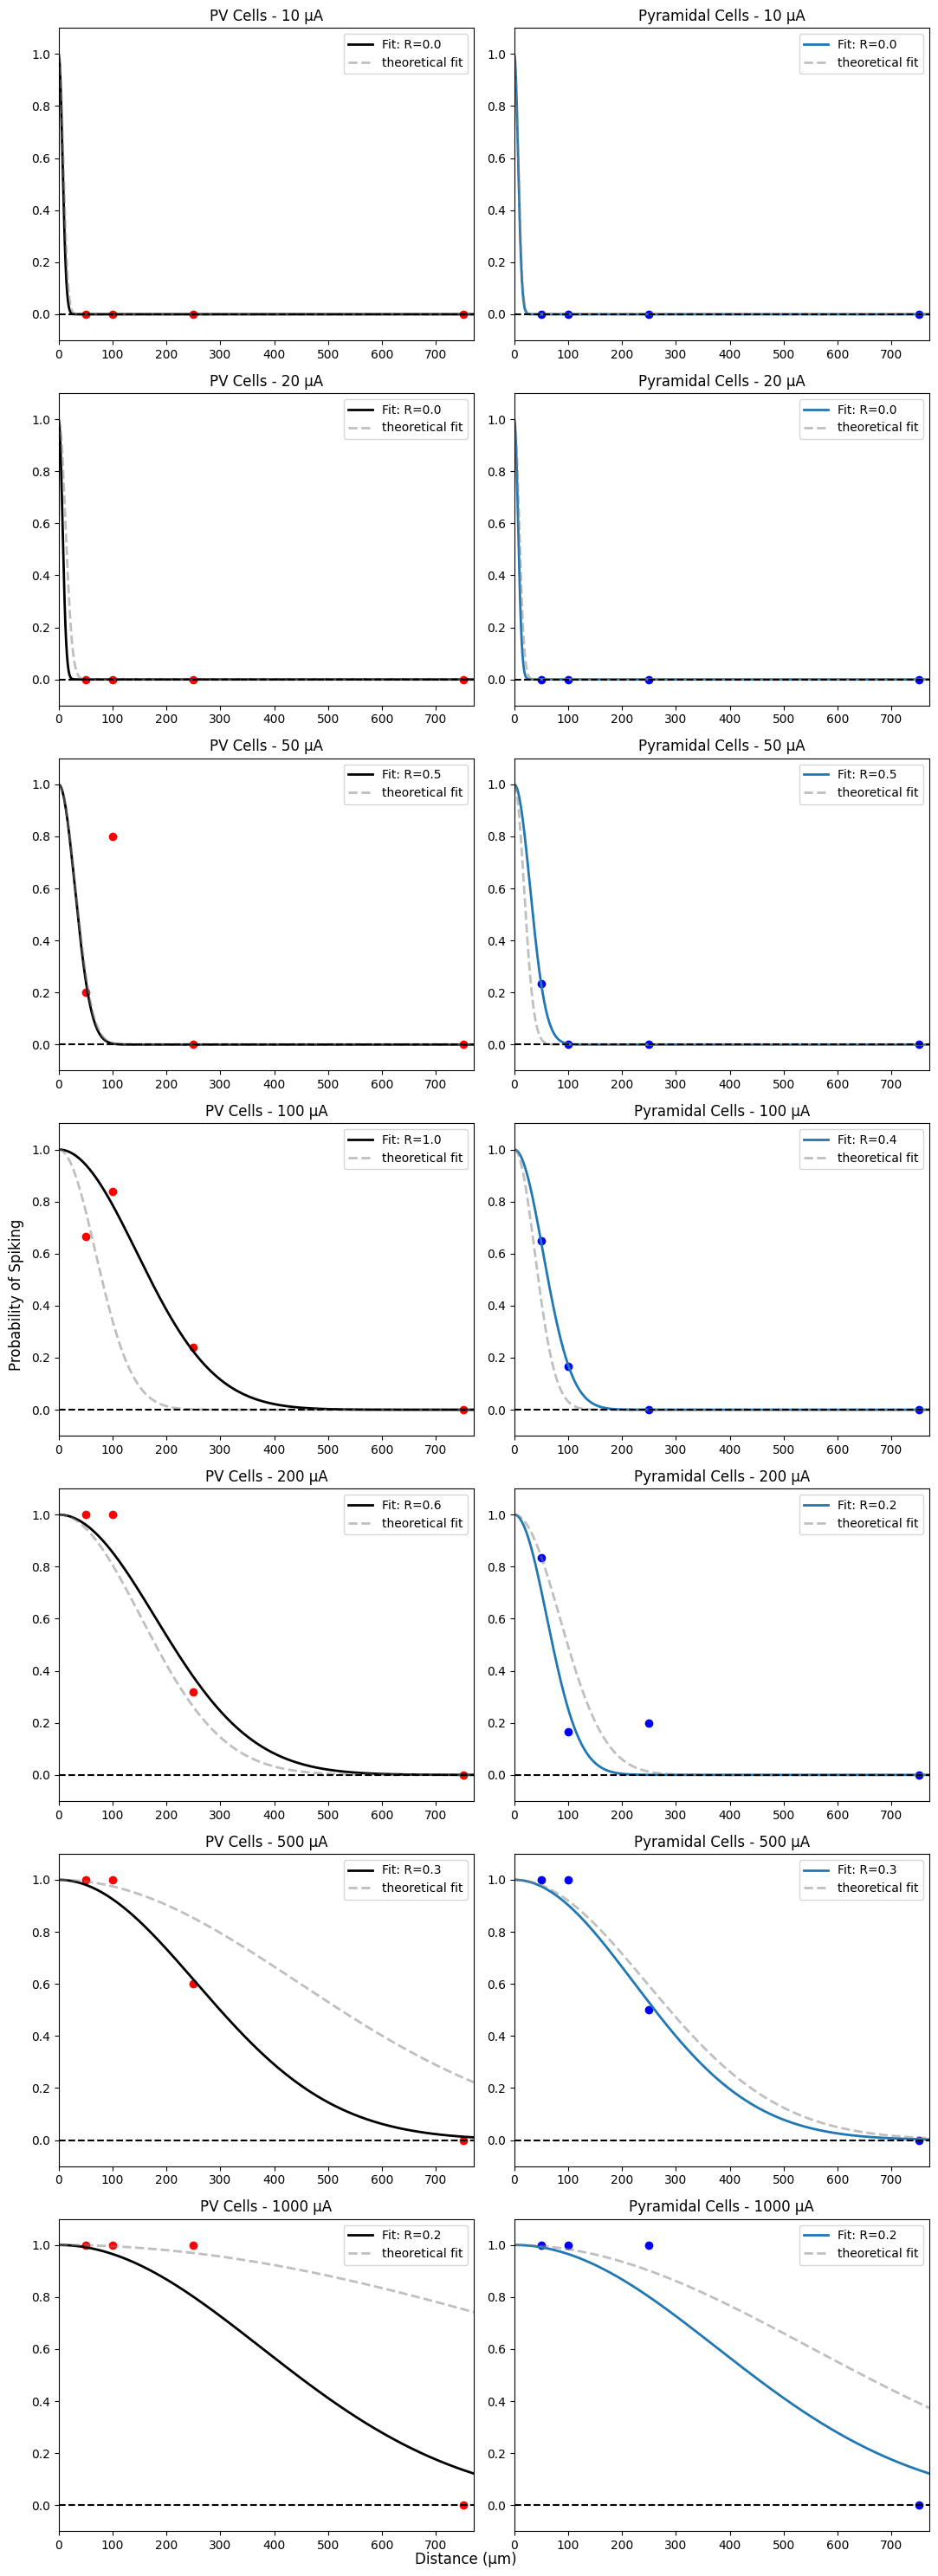

In [91]:
pyr_fits, pv_fits = {}, {}

for intensity, vals in pyr_data.items():
    x = vals["x"]
    y= vals["y"]
    
    p0 = [0.5]
    
    try:
        params1, cov1 = curve_fit(gauss_fit(intensity*1000), x, y, p0)
    except RuntimeError as e: 
        print("Pyr:", e, " for intensity", intensity)
    
    pyr_fits[intensity] = params1

for intensity, vals in pv_data.items():
    x = vals["x"]
    y= vals["y"]
    p0 = [0.5]

    try:
        params2, cov2 = curve_fit(gauss_fit(intensity*1000), x, y, p0=p0)
    except RuntimeError as e:
        print("PV:", e, " for intensity", intensity)
    
    pv_fits[intensity] = params2


fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(11, 30))
axes = axes.flatten()  

x_fit = np.linspace(0, 770, 500)
count = 0
for intensity in intensities:
    ax = axes[count]

    data = pv_data[intensity]
    ax.scatter(distances, data["y"], color='red')

    R = pv_fits[intensity][0]
    ax.plot(x_fit, gauss(x_fit, intensity*1000, R, 100), label=f"Fit: R={R:.1f}", linewidth=2, color="k")
    ax.plot(x_fit, gauss(x_fit, intensity*1000, 0.5, 100),
            label=f"theoretical fit",
            linewidth=2, color="gray", alpha=0.5, linestyle='dashed')
    ax.axhline(0, color='k', linestyle='dashed')
    ax.set_ylim(-0.1, 1.1)
    ax.set_xlim(0, 770)
    ax.set_title(f"PV Cells - {intensity*1000:.0f} μA")
    ax.legend()

    count += 1

    ax = axes[count]

    y = pyr_data[intensity]["y"]
    ax.scatter(distances, y, color='blue')

    R = pyr_fits[intensity][0]
    ax.plot(x_fit, gauss(x_fit, intensity*1000, R, 100), label=f"Fit: R={R:.1f}", linewidth=2)
    ax.plot(x_fit, gauss(x_fit, intensity*1000, 0.3, 100),
            label=f"theoretical fit",
            linewidth=2, color="gray", alpha=0.5, linestyle='dashed')
    ax.axhline(0, color='k', linestyle='dashed')
    ax.set_ylim(-0.1, 1.1)
    ax.set_xlim(0, 770)
    ax.set_title(f"Pyramidal Cells - {intensity*1000:.0f} μA")
    ax.legend()

    count += 1

fig.supylabel("Probability of Spiking")
fig.supxlabel("Distance (μm)")
fig.subplots_adjust(top=0.85)
plt.tight_layout()
plt.show()

# chatgpt fitting

In [19]:
def sig(x, x0, k):
    return 1 / (1 + np.exp(k * (x - x0)))

In [20]:
def guess_params(x, y):
    # x0 = distance where y is closest to 0.5
    idx = np.argmin(np.abs(y - 0.5))
    x0_guess = x[idx]

    # slope guess: approximate derivative around midpoint
    # avoids insane slopes
    k_guess = 1 / (0.25 * (np.max(x) - np.min(x)))

    return [x0_guess, k_guess]

In [21]:
def fit_sigmoid(x, y, yerr=None):
    p0 = guess_params(x, y)

    # bounds keep parameters reasonable
    # x0 must be inside measured range
    # k must be positive but limited
    bounds = (
        [np.min(x), 0],   # lower bounds: x0 >= min(x), k >= 0
        [np.max(x), 5]    # upper bounds: x0 <= max(x), k <= 5
    )

    params, cov = curve_fit(
        sig,
        x, y,
        p0=p0,
        sigma=yerr,
        absolute_sigma=True if yerr is not None else False,
        bounds=bounds,
        maxfev=20000
    )

    return params, cov



In [22]:
pyr_fits = {}
pv_fits = {}

for intensity, vals in pyr_data.items():
    x = vals["x"]
    y = vals["y"]
    yerr = vals.get("sd", None)  # IF you stored ±std dev

    pyr_fits[intensity], _ = fit_sigmoid(x, y, yerr)

for intensity, vals in pv_data.items():
    x = vals["x"]
    y = vals["y"]
    yerr = vals.get("sd", None)

    pv_fits[intensity], _ = fit_sigmoid(x, y, yerr)

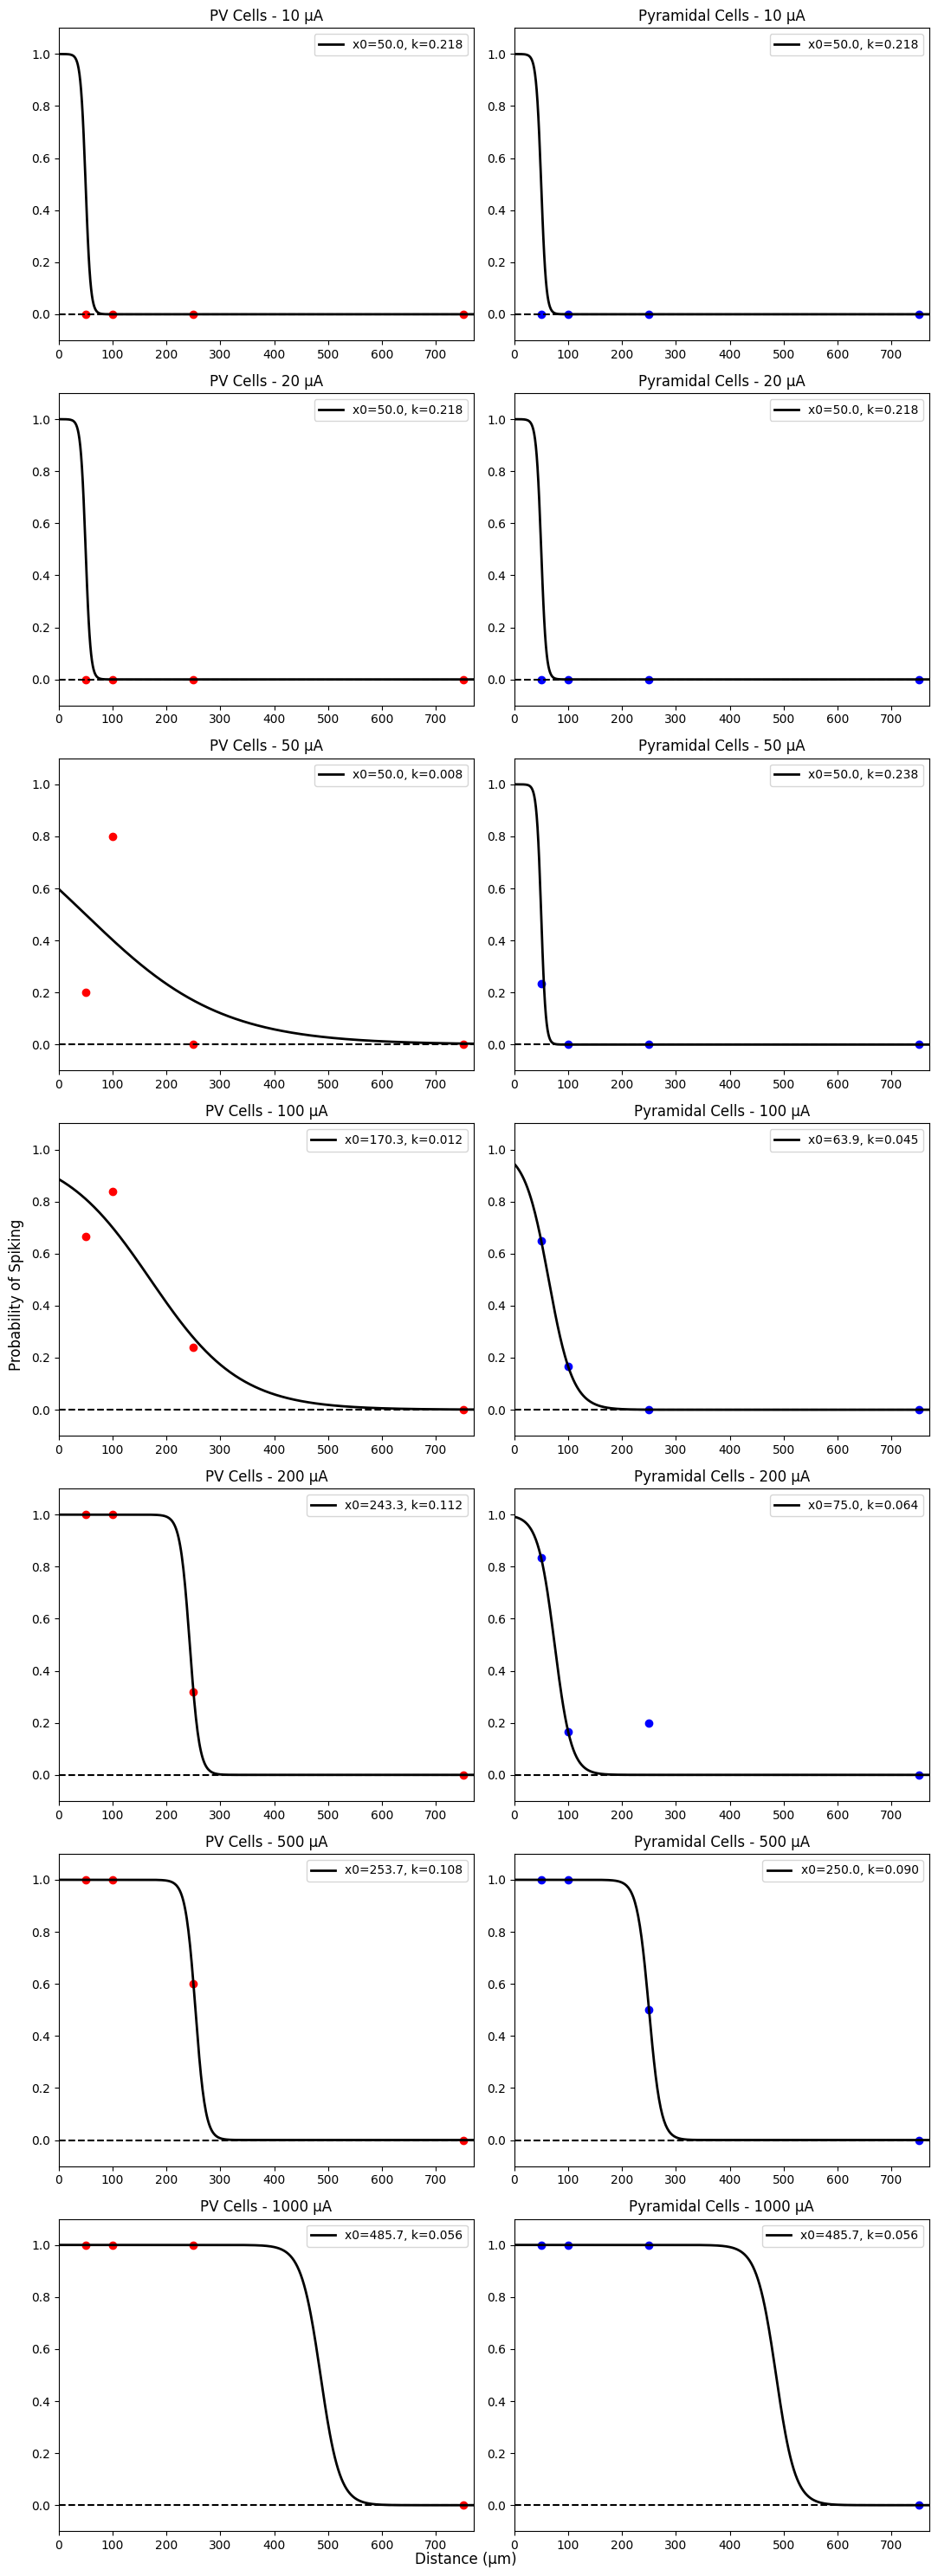

In [12]:
fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(11, 30))
axes = axes.flatten()

x_fit = np.linspace(0, 770, 500)
count = 0

for intensity in intensities:
    # PV PLOT ---------------------------------------------------
    ax = axes[count]
    data = pv_data[intensity]

    ax.scatter(data["x"], data["y"], color='red')

    x0, k = pv_fits[intensity]
    ax.plot(
        x_fit,
        sig(x_fit, x0, k),
        linewidth=2,
        color="k",
        label=f"x0={x0:.1f}, k={k:.3f}"
    )

    ax.axhline(0, color='k', linestyle='dashed')
    ax.set_ylim(-0.1, 1.1)
    ax.set_xlim(0, 770)
    ax.set_title(f"PV Cells - {intensity*1000:.0f} μA")
    ax.legend()
    count += 1

    ax = axes[count]
    data = pyr_data[intensity]

    ax.scatter(data["x"], data["y"], color='blue')

    x0, k = pyr_fits[intensity]
    ax.plot(
        x_fit,
        sig(x_fit, x0, k),
        linewidth=2,
        color="k",
        label=f"x0={x0:.1f}, k={k:.3f}"
    )

    ax.axhline(0, color='k', linestyle='dashed')
    ax.set_ylim(-0.1, 1.1)
    ax.set_xlim(0, 770)
    ax.set_title(f"Pyramidal Cells - {intensity*1000:.0f} μA")
    ax.legend()
    count += 1

fig.supylabel("Probability of Spiking")
fig.supxlabel("Distance (μm)")
fig.subplots_adjust(top=0.85)
plt.tight_layout()
plt.show()
